Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 - 4s - 642ms/step - loss: 0.0628 - val_loss: 0.0746
Epoch 2/50
7/7 - 0s - 29ms/step - loss: 0.0159 - val_loss: 0.0251
Epoch 3/50
7/7 - 0s - 38ms/step - loss: 0.0109 - val_loss: 0.0440
Epoch 4/50
7/7 - 0s - 25ms/step - loss: 0.0114 - val_loss: 0.0416
Epoch 5/50
7/7 - 0s - 41ms/step - loss: 0.0091 - val_loss: 0.0215
Epoch 6/50
7/7 - 0s - 47ms/step - loss: 0.0080 - val_loss: 0.0219
Epoch 7/50
7/7 - 0s - 38ms/step - loss: 0.0070 - val_loss: 0.0219
Epoch 8/50
7/7 - 0s - 43ms/step - loss: 0.0066 - val_loss: 0.0214
Epoch 9/50
7/7 - 0s - 24ms/step - loss: 0.0066 - val_loss: 0.0217
Epoch 10/50
7/7 - 0s - 43ms/step - loss: 0.0066 - val_loss: 0.0212
Epoch 11/50
7/7 - 0s - 43ms/step - loss: 0.0067 - val_loss: 0.0209
Epoch 12/50
7/7 - 0s - 43ms/step - loss: 0.0064 - val_loss: 0.0219
Epoch 13/50
7/7 - 0s - 43ms/step - loss: 0.0065 - val_loss: 0.0206
Epoch 14/50
7/7 - 0s - 43ms/step - loss: 0.0064 - val_loss: 0.0203
Epoch 15/50
7/7 - 0s - 28ms/step - loss: 0.0065 - val_loss: 0.0201
Epoch 16/50
7/

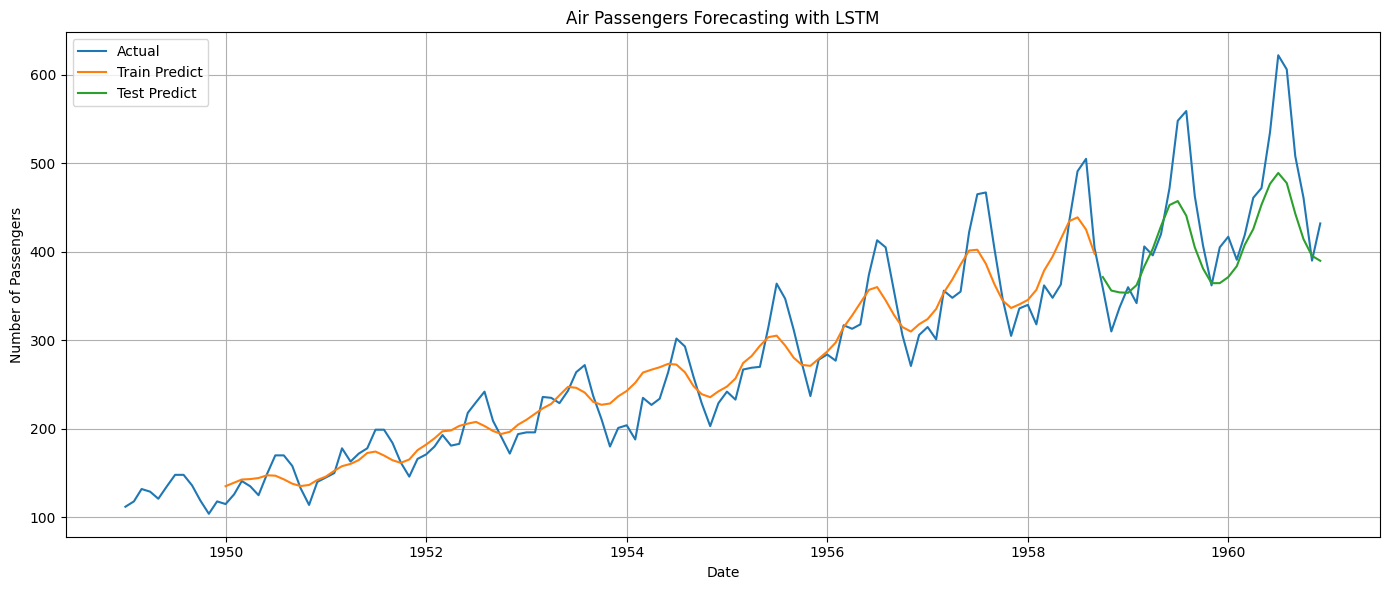

Actual passengers for 1960-12: 432
Predicted passengers for 1960-12: 389
Test set prediction accuracy (MAPE): 91.61%


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load dataset
data = pd.read_csv('AirPassengers.csv')
data['Month'] = pd.to_datetime(data['Month'])
data.rename(columns={'#Passengers': 'Passengers'}, inplace=True)
data.set_index('Month', inplace=True)

# Prepare data
dataset = data['Passengers'].values.astype('float32').reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
dataset_scaled = scaler.fit_transform(dataset)

# Create sequences
def create_dataset(dataset, look_back=12):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:i + look_back, 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

look_back = 12
X, y = create_dataset(dataset_scaled, look_back)

# Split into training and test sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape input to be [samples, time steps, features]
X_train = X_train.reshape((X_train.shape[0], look_back, 1))
X_test = X_test.reshape((X_test.shape[0], look_back, 1))

# Build LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(look_back, 1)))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=2, validation_data=(X_test, y_test))

# Predict
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform predictions and actuals
train_predict_inv = scaler.inverse_transform(train_predict)
test_predict_inv = scaler.inverse_transform(test_predict)
y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# Prepare plots with padding
train_predict_plot = np.empty_like(dataset)
train_predict_plot[:, :] = np.nan
train_predict_plot[look_back:look_back + len(train_predict_inv), :] = train_predict_inv

test_predict_plot = np.empty_like(dataset)
test_predict_plot[:, :] = np.nan
test_predict_plot[look_back + len(train_predict_inv):, :] = test_predict_inv

# Plot actual and predictions
plt.figure(figsize=(14, 6))
plt.plot(data.index, dataset, label='Actual')
plt.plot(data.index, train_predict_plot, label='Train Predict')
plt.plot(data.index, test_predict_plot, label='Test Predict')
plt.title("Air Passengers Forecasting with LSTM")
plt.xlabel("Date")
plt.ylabel("Number of Passengers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print last actual and predicted values for end of test set
print(f"Actual passengers for {data.index[-1].strftime('%Y-%m')}: {int(dataset[-1][0])}")
print(f"Predicted passengers for {data.index[-1].strftime('%Y-%m')}: {int(test_predict_inv[-1][0])}")

# Calculate MAPE for test set
mape = np.mean(np.abs((y_test_inv - test_predict_inv) / y_test_inv)) * 100
print(f"Test set prediction accuracy (MAPE): {100 - mape:.2f}%")
